Loaded checkpoint from 'swin\good_98\swin_balanced_best.pth' (Epoch 30)
Running inference on 16 images...
Prediction image saved as: test_output.png


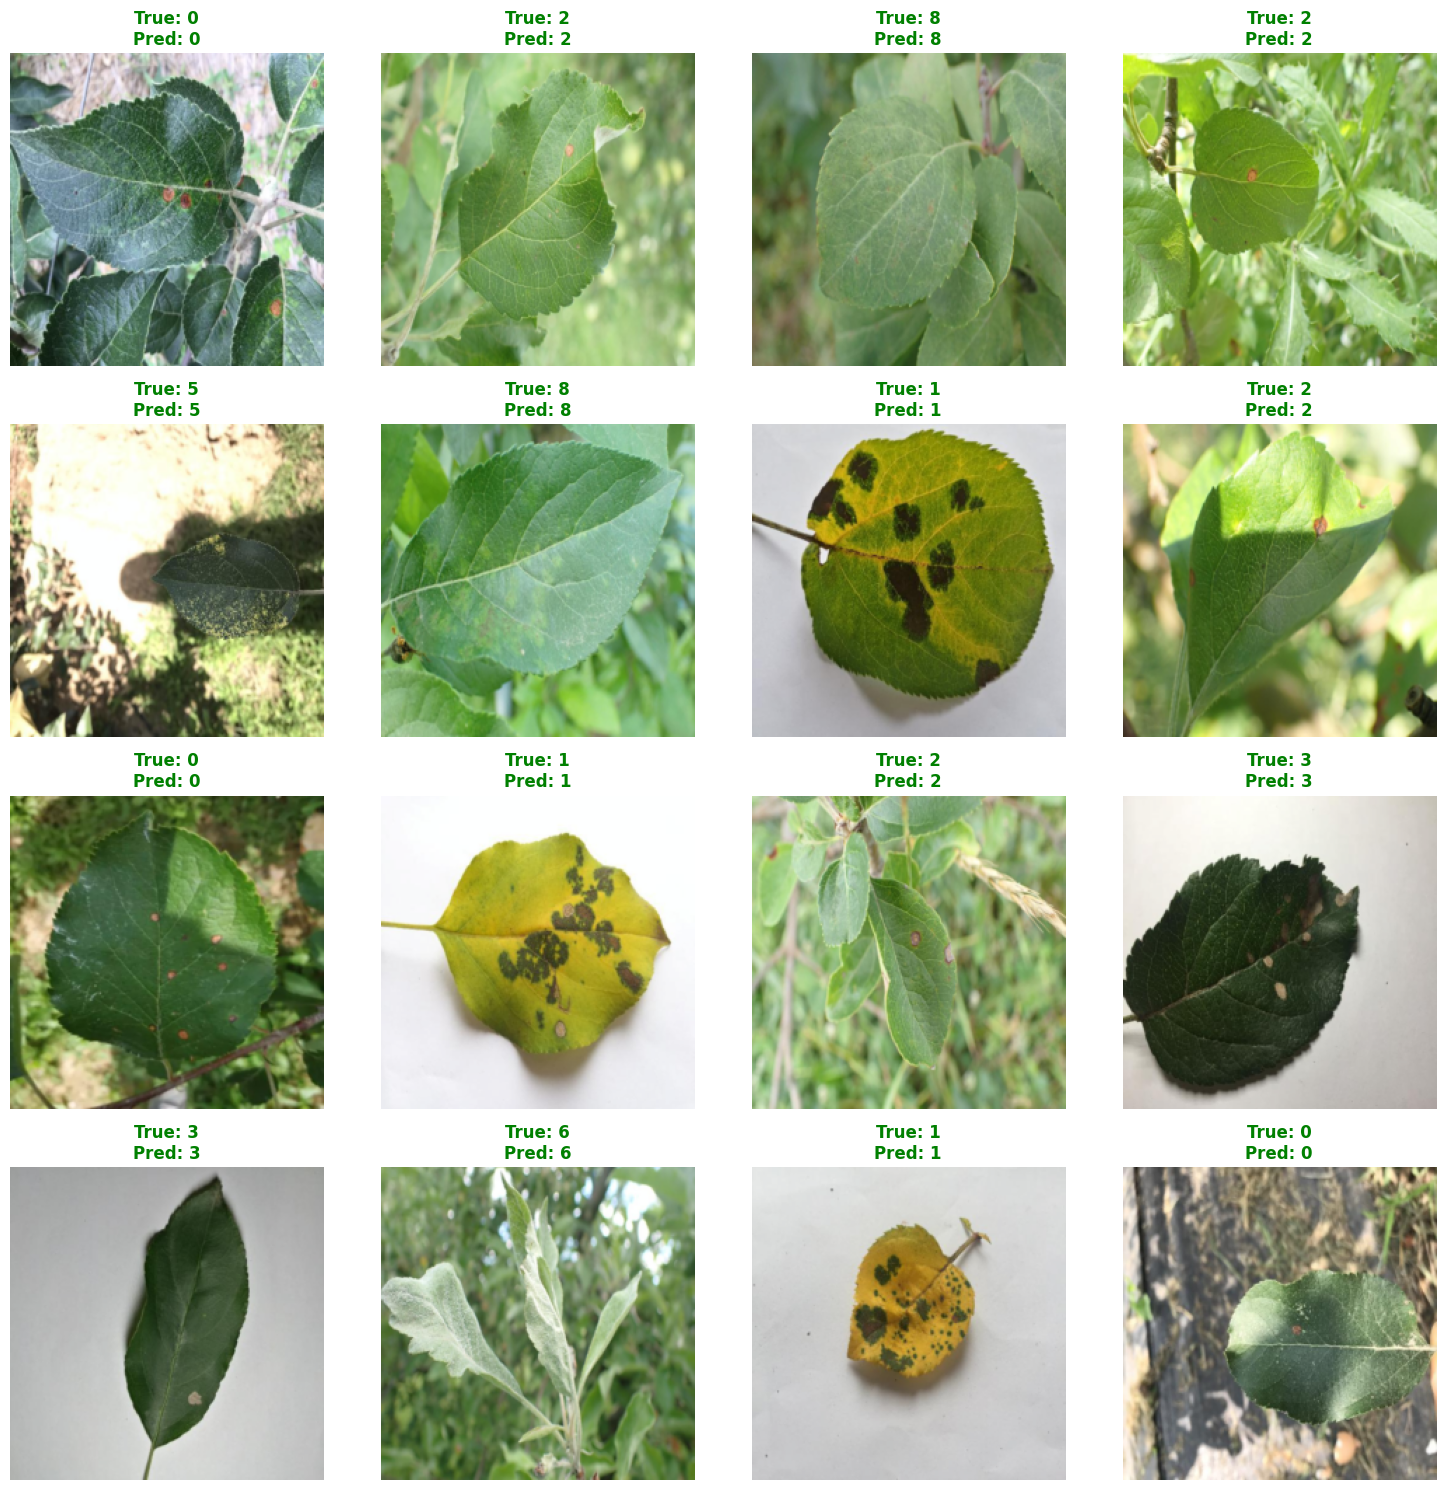

In [3]:
import os
import yaml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
from PIL import Image
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import timm  # For Swin Transformer
import random

# ==================== 1. DATASET CLASS ====================
class BalancedAppleLeafDataset(Dataset):
    """Dataset class with support for class balancing"""
    
    def __init__(self, data_dir, split='train', transform=None, balance_method='oversample'):
        self.data_dir = Path(data_dir)
        self.split = split
        self.transform = transform
        self.balance_method = balance_method
        
        # Load YAML config
        yaml_path = self.data_dir / 'data.yaml'
        with open(yaml_path, 'r') as f:
            config = yaml.safe_load(f)
        
        self.class_names = config['names']
        self.n_classes = config['nc']
        
        # Get paths
        if split == 'val':
            split = 'valid' if 'valid' in config else 'val'
        
        img_path = config[split].replace('../', '')
        self.img_dir = self.data_dir / img_path
        self.label_dir = Path(str(self.img_dir).replace('images', 'labels').replace('image', 'labels'))
        
        # Load all image paths and labels
        self.samples = []
        self.labels = []
        self._load_dataset()
        
        # Balance only training set
        if split == 'train' and balance_method != 'none':
            self._balance_dataset()

    def _load_dataset(self):
        image_files = list(self.img_dir.glob('*.jpg')) + list(self.img_dir.glob('*.png'))
        for img_path in image_files:
            label_path = self.label_dir / (img_path.stem + '.txt')
            if label_path.exists():
                with open(label_path, 'r') as f:
                    line = f.readline().strip()
                    if line:
                        class_id = int(line.split()[0])
                        self.samples.append(str(img_path))
                        self.labels.append(class_id)
    
    def _balance_dataset(self):
        # (Balancing logic omitted for brevity as we are testing, but class structure remains)
        pass

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path = self.samples[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# ==================== 2. MODEL CLASS ====================
class SwinTransformerClassifier:
    """Swin Transformer for Apple Leaf Classification"""
    
    def __init__(self, data_dir, n_classes=9, img_size=224, balance_method='oversample'):
        self.data_dir = data_dir
        self.n_classes = n_classes
        self.img_size = img_size
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load YAML config for class names
        yaml_path = Path(data_dir) / 'data.yaml'
        with open(yaml_path, 'r') as f:
            config = yaml.safe_load(f)
        self.class_names = config['names']
        
        # Initialize model
        self.model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=self.n_classes)
        self.model = self.model.to(self.device)
        
        # Define transforms (Standard ImageNet normalization)
        self.val_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # Initialize Test Dataset
        self.test_dataset = BalancedAppleLeafDataset(
            data_dir, 'test', self.val_transform, balance_method='none'
        )

    def load_model(self, path):
        """Load a saved model checkpoint"""
        if not os.path.exists(path):
            raise FileNotFoundError(f"Model file not found: {path}")
            
        checkpoint = torch.load(path, map_location=self.device)
        
        # Handle different saving formats (state_dict vs full checkpoint)
        if 'model_state_dict' in checkpoint:
            self.model.load_state_dict(checkpoint['model_state_dict'])
            print(f"Loaded checkpoint from '{path}' (Epoch {checkpoint.get('epoch', '?')})")
        else:
            self.model.load_state_dict(checkpoint)
            print(f"Loaded state dictionary from '{path}'")

# ==================== 3. VISUALIZATION FUNCTION ====================
def visualize_test_results(classifier, num_samples=16, save_name='test_predictions.png'):
    """Runs inference and saves a grid image."""
    classifier.model.eval()
    dataset = classifier.test_dataset
    class_names = classifier.class_names
    device = classifier.device
    
    # 1. Select random indices
    total_images = len(dataset)
    if total_images == 0:
        print("Error: Test dataset is empty!")
        return

    indices = random.sample(range(total_images), min(num_samples, total_images))
    
    # 2. Setup Plot
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    axes = axes.flatten()
    
    print(f"Running inference on {len(indices)} images...")

    # 3. Iterate through samples
    with torch.no_grad():
        for i, idx in enumerate(indices):
            if i >= len(axes): break
            
            # Get data
            img_tensor, label_idx = dataset[idx]
            
            # Prepare for model [1, C, H, W]
            img_input = img_tensor.unsqueeze(0).to(device)
            
            # Inference
            output = classifier.model(img_input)
            _, pred_idx = torch.max(output, 1)
            pred_idx = pred_idx.item()
            
            # Un-normalize image for display
            # (Reversing: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            
            img_display = img_tensor.cpu().numpy().transpose((1, 2, 0))
            img_display = std * img_display + mean
            img_display = np.clip(img_display, 0, 1)
            
            # Plotting
            ax = axes[i]
            ax.imshow(img_display)
            
            true_name = class_names[label_idx]
            pred_name = class_names[pred_idx]
            
            # Green if Correct, Red if Wrong
            color = 'green' if label_idx == pred_idx else 'red'
            
            ax.set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontweight='bold')
            ax.axis('off')
            
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(save_name)
    print(f"Prediction image saved as: {save_name}")

# ==================== 4. MAIN EXECUTION ====================
if __name__ == "__main__":
    # --- CONFIGURATION ---
    DATA_DIR = "appleleaf.v2i.yolo26"
    MODEL_PATH = "swin\good_98\swin_balanced_best.pth"  # Ensure this file exists
    
    try:
        # Initialize Wrapper
        classifier = SwinTransformerClassifier(
            data_dir=DATA_DIR,
            n_classes=9,  # Ensure this matches your training
            img_size=224
        )
        
        # Load Weights
        classifier.load_model(MODEL_PATH)
        
        # Run Visualization
        visualize_test_results(classifier, num_samples=16, save_name='test_output.png')
        
    except Exception as e:
        print(f"\nError detected: {e}")


Evaluating on 400 test images...


Testing: 100%|██████████| 13/13 [00:36<00:00,  2.81s/it]



Overall Test Accuracy: 98.50%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        40
           1       1.00      0.97      0.99        38
           2       1.00      1.00      1.00        54
           3       0.92      0.95      0.93        37
           4       0.98      0.98      0.98        42
           5       1.00      1.00      1.00        32
           6       1.00      1.00      1.00        59
           7       1.00      1.00      1.00        47
           8       0.98      1.00      0.99        51

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.99      0.98      0.99       400

Confusion Matrix saved to ./confusion_matrix.png


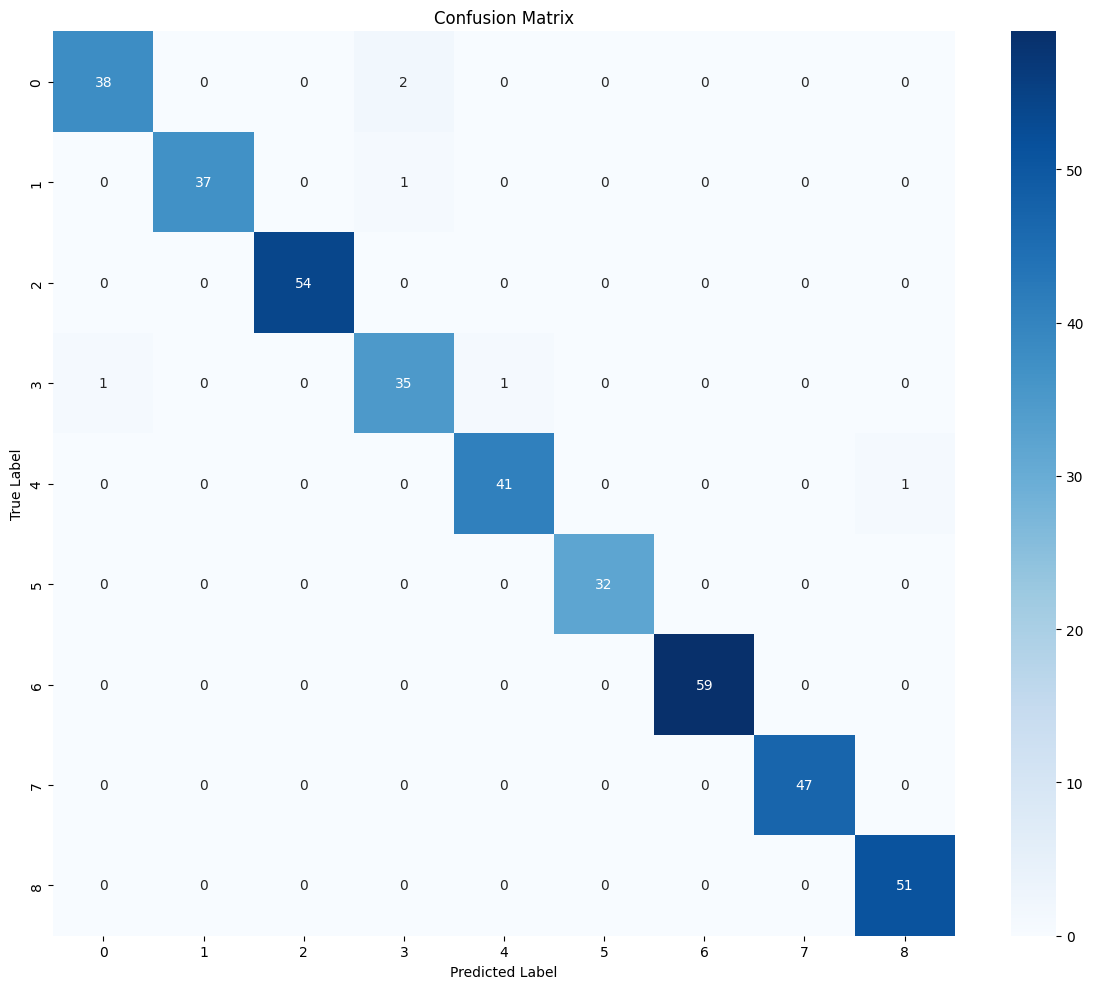

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import DataLoader
from tqdm import tqdm
import pandas as pd

# Assume 'classifier' is your loaded SwinTransformerClassifier instance from the previous step
# If not, initialize it and load weights first (see previous code block)

def evaluate_model_performance(classifier, batch_size=32, save_dir='.'):
    """
    Generates a comprehensive performance report.
    """
    
    # 1. Setup
    classifier.model.eval()
    
    # FIX: Set num_workers=0 to avoid RuntimeError
    test_loader = DataLoader(
        classifier.test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=0  # <--- CHANGED FROM 4 TO 0
    )
    
    device = classifier.device
    class_names = classifier.class_names
    
    print(f"\nEvaluating on {len(classifier.test_dataset)} test images...")
    
    # 2. Run Inference
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        # Using tqdm for progress bar
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(device)
            outputs = classifier.model(images)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # 3. Calculate Metrics
    # --- Overall Accuracy ---
    acc = accuracy_score(all_labels, all_preds)
    print(f"\n{'='*40}")
    print(f"Overall Test Accuracy: {acc*100:.2f}%")
    print(f"{'='*40}")

    # --- Classification Report ---
    print("\nDetailed Classification Report:")
    report_str = classification_report(all_labels, all_preds, target_names=class_names)
    print(report_str)
    
    # --- Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/confusion_matrix.png")
    print(f"Confusion Matrix saved to {save_dir}/confusion_matrix.png")
    plt.show()

# ==================== MAIN EXECUTION ====================
if __name__ == "__main__":
    # Ensure this block runs AFTER initializing 'classifier' and loading weights
    # (Copy the setup code from the previous response if needed)
    
    try:
        evaluate_model_performance(classifier)
    except NameError:
        print("Error: 'classifier' is not defined. Please run the model initialization code first.")
